hi
Final CG Offset from Origin (X coordinate): -0.00 mm
Final CG Offset from Origin (Y coordinate): -0.00 mm


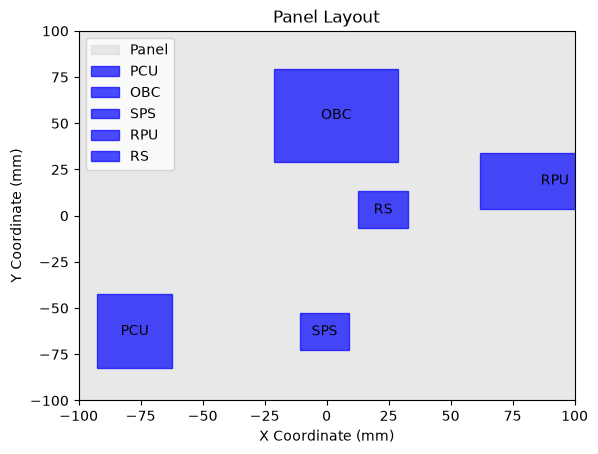

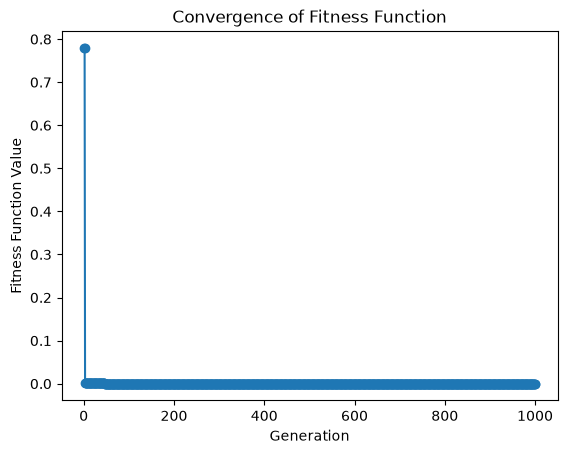

In [4]:
# Sir's code
print("hi")

import random
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution

# Define the fitness function (minimize the CG offset from the origin)
def evaluate(individual, element_data, element_names):
    masses = element_data[:, 0].astype(float) # Convert mass values to floats
    total_mass = sum(masses)
    cg_x = sum(x * mass for x, mass in zip(individual[::2], masses)) / total_mass
    cg_y = sum(y * mass for y, mass in zip(individual[1::2], masses)) / total_mass
    return (cg_x ** 2 + cg_y ** 2) # Squared distance to the origin

# Get user input for panel size and number of elements
panel_width = float(input("Enter panel width (in mm): "))
panel_height = float(input("Enter panel height (in mm): "))
num_elements = int(input("Enter the number of elements: "))

# Initialize lists to store element data
element_data = []
element_names = []

# Get user input for each element's name, length, width, and mass
for i in range(num_elements):
    element_name = input(f"Enter name of Element {i + 1}: ")
    length = float(input(f"Enter length of Element {i + 1} (in mm): "))
    width = float(input(f"Enter width of Element {i + 1} (in mm): "))
    mass = float(input(f"Enter mass of Element {i + 1} (in kg): "))
    
    element_data.append([mass, length, width])
    element_names.append(element_name)

# Convert element_data to a NumPy array
element_data = np.array(element_data, dtype=float)

# Define bounds for DE optimization
bounds = [(-panel_width/2, panel_width/2), (-panel_height/2, panel_height/2)] * num_elements

# Create a callback function to track convergence
convergence_data = []

def callback(xk, convergence=None):
    convergence_data.append(evaluate(xk, element_data, element_names))

# Perform Differential Evolution optimization
result = differential_evolution(
    evaluate, 
    bounds, 
    args=(element_data, element_names), 
    maxiter=1000, 
    popsize=100, 
    tol=1e-6, 
    strategy='best1bin', 
    callback=callback
)

# Extract the best individual and its fitness value
best_individual = result.x
best_fitness_value = result.fun

# Calculate and display the minimized CG offset
total_mass = sum([data[0] for data in element_data])
final_cg_x = sum(x * data[0] for x, data in zip(best_individual[::2], element_data)) / total_mass
final_cg_y = sum(y * data[0] for y, data in zip(best_individual[1::2], element_data)) / total_mass

print(f"Final CG Offset from Origin (X coordinate): {final_cg_x:.2f} mm")
print(f"Final CG Offset from Origin (Y coordinate): {final_cg_y:.2f} mm")

# Create a figure and axis for plotting
fig, ax = plt.subplots()

# Plot the panel as a rectangle
panel_rect = plt.Rectangle(
    (-panel_width/2, -panel_height/2), 
    panel_width, 
    panel_height, 
    color='lightgray', 
    alpha=0.5, 
    label='Panel'
)
ax.add_patch(panel_rect)

# Plot the elements on the panel and display element names
for i, element_pos in enumerate(best_individual):
    if i % 2 == 0:
        element_length = element_data[i//2][1]
        element_width = element_data[i//2][2]
        element_rect = plt.Rectangle(
            (element_pos - element_length/2, best_individual[i+1] - element_width/2), 
            element_length, 
            element_width, 
            color='blue', 
            alpha=0.7, 
            label=element_names[i//2]
        )
        ax.add_patch(element_rect)
        
        # Display element name as text label
        element_label_x = element_pos
        element_label_y = best_individual[i + 1]
        ax.text(element_label_x, element_label_y, element_names[i//2], color='black', ha='center', va='center')

# Set axis limits and labels
ax.set_xlim(-panel_width/2, panel_width/2)
ax.set_ylim(-panel_height/2, panel_height/2)
ax.set_xlabel("X Coordinate (mm)")
ax.set_ylabel("Y Coordinate (mm)")

# Add a legend
ax.legend()
plt.title("Panel Layout")
plt.show()

# Plot the convergence of the fitness function (extracted from Sir's code)
plt.figure()
plt.plot(range(1, len(convergence_data) + 1), convergence_data, marker='o', linestyle='-')
plt.xlabel("Generation")
plt.ylabel("Fitness Function Value")
plt.title("Convergence of Fitness Function")
plt.show()

Searching for 5 unique non-overlapping configurations...
Identified valid unique configuration 1/5
Identified valid unique configuration 2/5
Identified valid unique configuration 3/5
Identified valid unique configuration 4/5


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Identified valid unique configuration 5/5

Successfully identified 5 unique configurations.

Configuration 1:
-------------------------------------------------------
CG Offset X: -0.0000 mm | CG Offset Y: -0.0000 mm
Element              Center X        Center Y       
-------------------------------------------------------
PCU                  -32.6756        -46.1148       
OBC                  36.3141         -31.2584       
SPS                  48.3523         36.9432        
RPU                  -25.2494        20.2116        
RS                   -29.2192        51.2441        


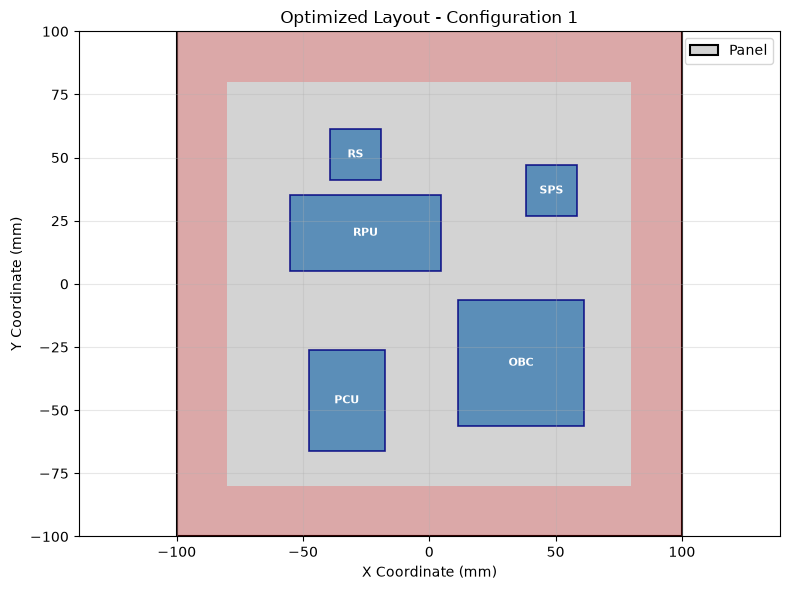

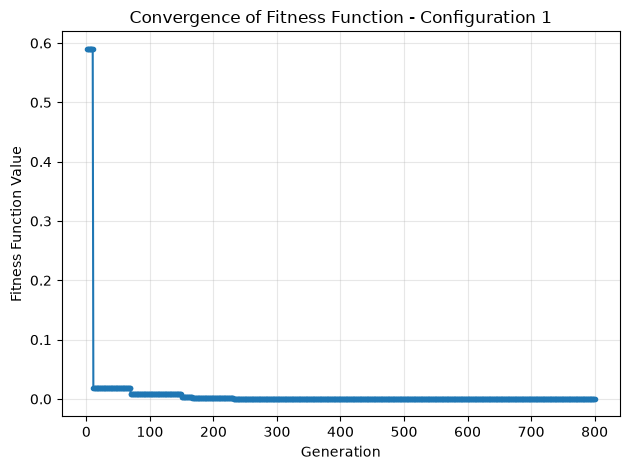

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Configuration 2:
-------------------------------------------------------
CG Offset X: -0.0000 mm | CG Offset Y: -0.0000 mm
Element              Center X        Center Y       
-------------------------------------------------------
PCU                  -15.7266        -36.3190       
OBC                  30.9956         22.1545        
SPS                  54.2684         -58.9369       
RPU                  41.0491         -18.1330       
RS                   -63.0784        33.3503        


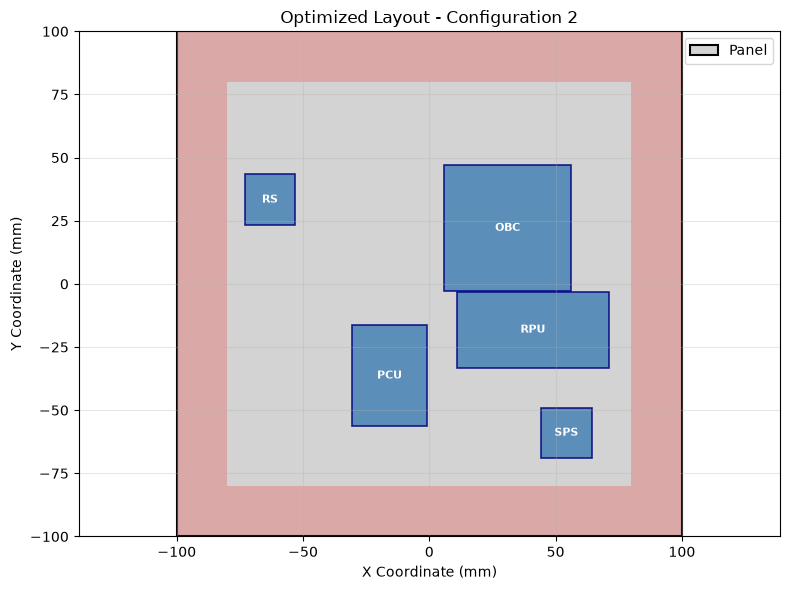

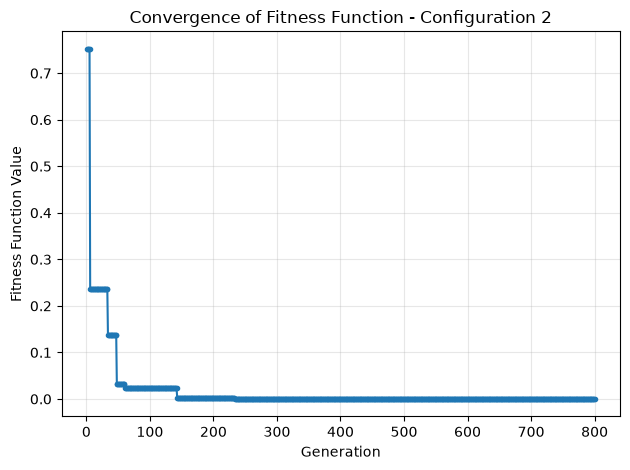

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Configuration 3:
-------------------------------------------------------
CG Offset X: -0.0000 mm | CG Offset Y: -0.0000 mm
Element              Center X        Center Y       
-------------------------------------------------------
PCU                  24.1708         -36.5858       
OBC                  -34.4126        -27.4075       
SPS                  53.2244         48.0870        
RPU                  3.4639          56.0577        
RS                   -1.1113         21.1611        


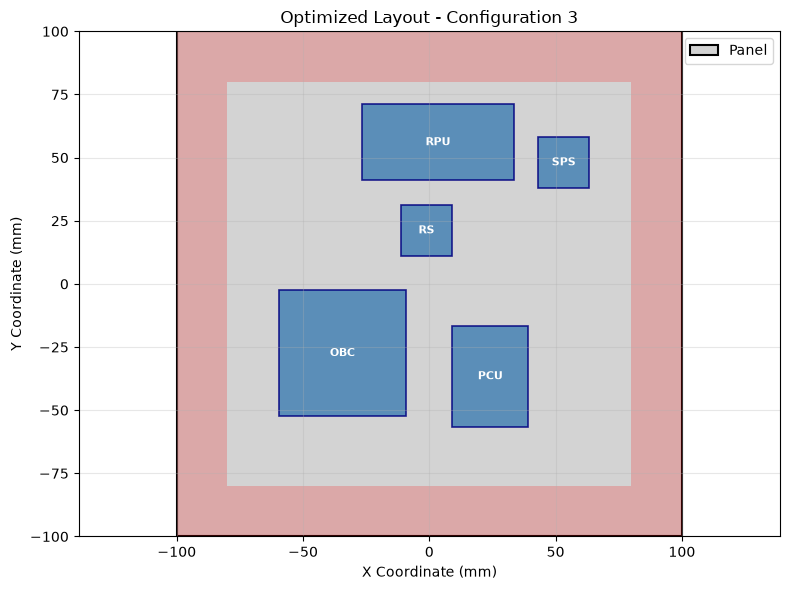

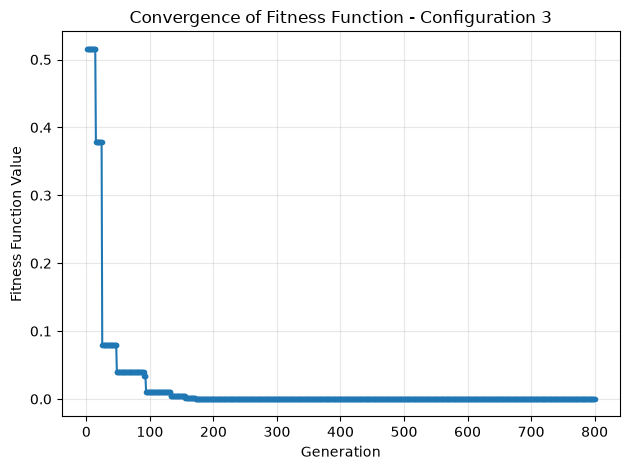

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Configuration 4:
-------------------------------------------------------
CG Offset X: -0.0000 mm | CG Offset Y: -0.0000 mm
Element              Center X        Center Y       
-------------------------------------------------------
PCU                  12.7071         -40.7810       
OBC                  -46.2086        -18.6915       
SPS                  44.2388         65.3032        
RPU                  -33.6305        62.5083        
RS                   39.6681         4.2966         


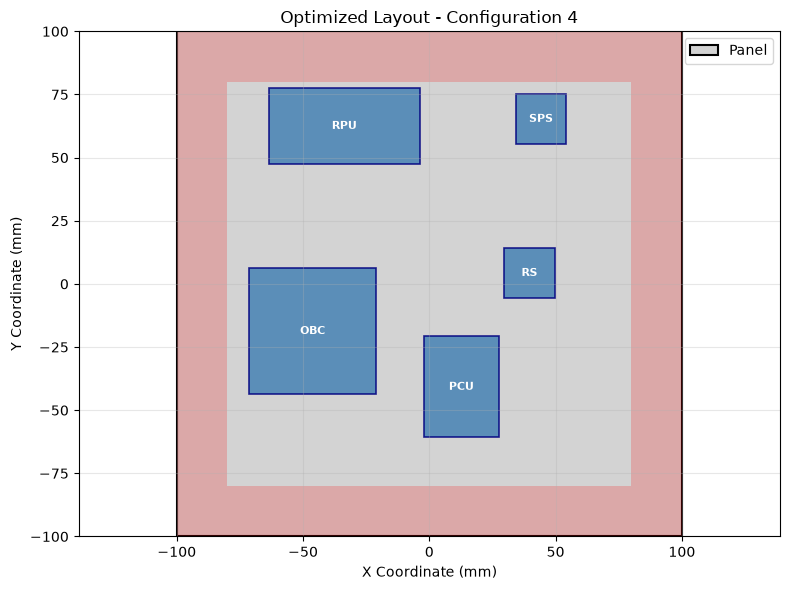

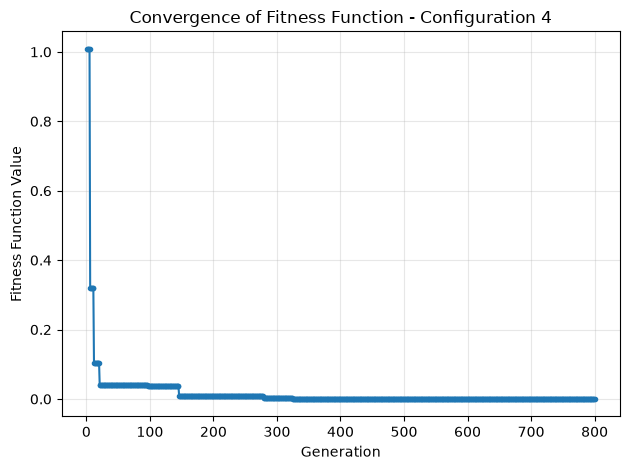

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Configuration 5:
-------------------------------------------------------
CG Offset X: -0.0000 mm | CG Offset Y: -0.0000 mm
Element              Center X        Center Y       
-------------------------------------------------------
PCU                  -1.7911         -57.4133       
OBC                  -11.5352        35.5686        
SPS                  -23.8313        -15.4047       
RPU                  49.4770         63.4137        
RS                   7.1836          -14.6072       


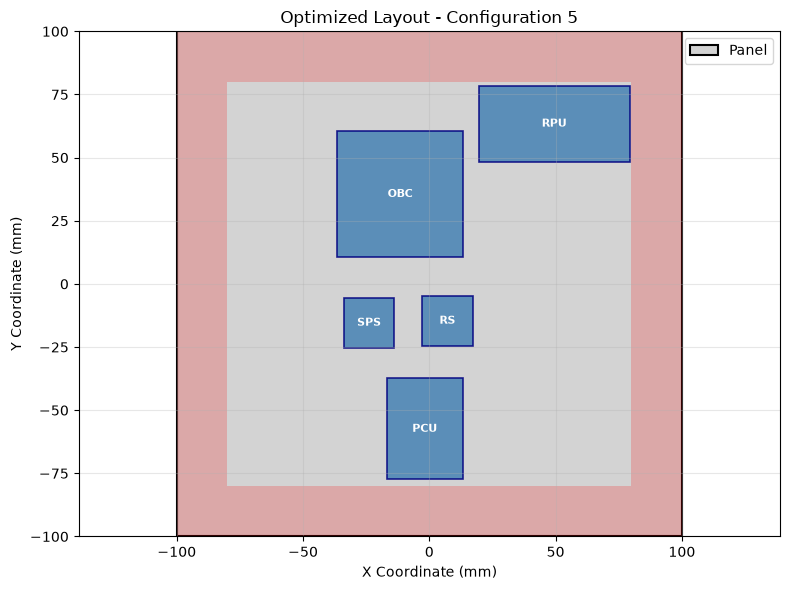

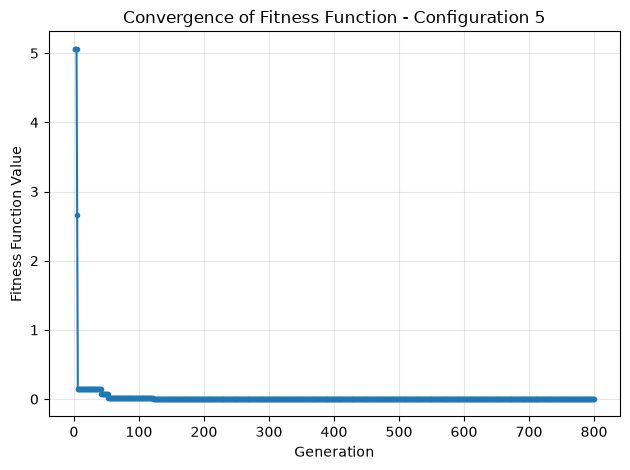

Process complete.


In [5]:
# Constraint 1: Added user defined borders
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution

def evaluate(individual, element_data, num_elements):
    """Computes the squared center-of-gravity offset and applies a continuous
    penalty for any inter-element overlaps."""
    masses = element_data[:, 0]
    total_mass = np.sum(masses)
    cg_x = sum(x * m for x, m in zip(individual[::2], masses)) / total_mass
    cg_y = sum(y * m for y, m in zip(individual[1::2], masses)) / total_mass
    base_fitness = cg_x**2 + cg_y**2

    # Overlap penalty calculation
    penalty = 0.0
    penalty_scale = 1e8  # Scales penalty relative to typical CG fitness values
    for i in range(num_elements):
        xi, yi = individual[2 * i], individual[2 * i + 1]
        li, wi = element_data[i, 1], element_data[i, 2]
        for j in range(i + 1, num_elements):
            xj, yj = individual[2 * j], individual[2 * j + 1]
            lj, wj = element_data[j, 1], element_data[j, 2]
            
            # Calculate penetration dimensions along each axis
            x_penetration = max(0.0, (li + lj) / 2.0 - abs(xi - xj))
            y_penetration = max(0.0, (wi + wj) / 2.0 - abs(yi - yj))
            
            # Penalty applies only when elements overlap in both dimensions
            if x_penetration > 1e-6 and y_penetration > 1e-6:
                penalty += x_penetration * y_penetration * penalty_scale

    return base_fitness + penalty

def is_feasible(individual, element_data, num_elements):
    """Strict validation to confirm zero overlap between all elements."""
    for i in range(num_elements):
        for j in range(i + 1, num_elements):
            xi, yi = individual[2 * i], individual[2 * i + 1]
            xj, yj = individual[2 * j], individual[2 * j + 1]
            li, wi = element_data[i, 1], element_data[i, 2]
            lj, wj = element_data[j, 1], element_data[j, 2]
            x_penetration = max(0.0, (li + lj) / 2.0 - abs(xi - xj))
            y_penetration = max(0.0, (wi + wj) / 2.0 - abs(yi - yj))
            if x_penetration > 1e-4 and y_penetration > 1e-4:
                return False
    return True

def main():
    # Input collection
    panel_width = float(input("Enter panel width (in mm): "))
    panel_height = float(input("Enter panel height (in mm): "))
    num_elements = int(input("Enter the number of elements: "))
    border_spacing = float(input("Enter border spacing from all sides (in mm): "))
    
    element_data = []
    element_names = []
    for i in range(num_elements):
        name = input(f"Enter name of Element {i + 1}: ")
        length = float(input(f"Enter length of Element {i + 1} (in mm): "))
        width = float(input(f"Enter width of Element {i + 1} (in mm): "))
        mass = float(input(f"Enter mass of Element {i + 1} (kg): "))
        element_data.append([mass, length, width])
        element_names.append(name)
        
    element_data = np.array(element_data, dtype=float)

    # Pre-check feasibility against single-element border constraint
    working_width = panel_width - 2 * border_spacing
    working_height = panel_height - 2 * border_spacing
    bounds = []
    possible = True

    for i in range(num_elements):
        length = element_data[i, 1]
        width = element_data[i, 2]
        if length > working_width or width > working_height:
            possible = False
            print(f"Design infeasible: Element '{element_names[i]}' ({length}x{width} mm) exceeds the available working area of {working_width}x{working_height} mm.")
            break
        x_min = -panel_width / 2 + border_spacing + length / 2
        x_max = panel_width / 2 - border_spacing - length / 2
        y_min = -panel_height / 2 + border_spacing + width / 2
        y_max = panel_height / 2 - border_spacing - width / 2
        bounds.append((x_min, x_max))
        bounds.append((y_min, y_max))

    if not possible:
        print("Design infeasible. Please adjust element dimensions, border spacing, or panel size.")
        return

    # Multi-solution search parameters
    num_desired = 5
    uniqueness_tolerance = 0.5  # mm
    unique_solutions = []
    convergence_records = []  # Stores convergence data for each valid solution
    max_attempts = 120

    print(f"Searching for {num_desired} unique non-overlapping configurations...")

    for attempt in range(1, max_attempts + 1):
        if len(unique_solutions) >= num_desired:
            break
        convergence_data = []

        def capture_convergence(x, convergence=None):
            convergence_data.append(evaluate(x, element_data, num_elements))

        seed = np.random.randint(0, 1000000)
        result = differential_evolution(
            evaluate, bounds, args=(element_data, num_elements),
            maxiter=800, popsize=100, tol=1e-6, strategy='best1bin',
            seed=seed, callback=capture_convergence
        )
        candidate = result.x

        if not is_feasible(candidate, element_data, num_elements):
            continue

        is_unique = True
        for existing in unique_solutions:
            if np.max(np.abs(candidate - existing)) < uniqueness_tolerance:
                is_unique = False
                break

        if is_unique:
            unique_solutions.append(candidate)
            convergence_records.append(list(convergence_data))
            print(f"Identified valid unique configuration {len(unique_solutions)}/{num_desired}")

    if len(unique_solutions) < num_desired:
        print(f"\nOnly {len(unique_solutions)} unique configuration(s) found out of {num_desired} requested.")
        print(f"Reason: The optimizer could not locate {num_desired} distinct non-overlapping layouts within {max_attempts} attempts.")
    else:
        print(f"\nSuccessfully identified {num_desired} unique configurations.\n")

    # Output and visualization for each solution
    for idx, sol in enumerate(unique_solutions, 1):
        total_mass = np.sum(element_data[:, 0])
        final_cg_x = sum(x * m for x, m in zip(sol[::2], element_data[:, 0])) / total_mass
        final_cg_y = sum(y * m for y, m in zip(sol[1::2], element_data[:, 0])) / total_mass

        print(f"Configuration {idx}:")
        print("-" * 55)
        print(f"CG Offset X: {final_cg_x:.4f} mm | CG Offset Y: {final_cg_y:.4f} mm")
        print(f"{'Element':<20} {'Center X':<15} {'Center Y':<15}")
        print("-" * 55)
        for i in range(num_elements):
            print(f"{element_names[i]:<20} {sol[2*i]:<15.4f} {sol[2*i+1]:<15.4f}")

        # LAYOUT PLOT
        fig, ax = plt.subplots(figsize=(8, 6))
        ax.set_xlim(-panel_width / 2, panel_width / 2)
        ax.set_ylim(-panel_height / 2, panel_height / 2)
        ax.set_xlabel("X Coordinate (mm)")
        ax.set_ylabel("Y Coordinate (mm)")
        ax.set_title(f"Optimized Layout - Configuration {idx}")
        ax.grid(True, alpha=0.3)
        ax.set_aspect('equal', adjustable='datalim')

        ax.add_patch(plt.Rectangle((-panel_width/2, -panel_height/2), panel_width, panel_height,
                                facecolor='lightgray', edgecolor='black', linewidth=1.5, label='Panel'))

        # Border exclusion zones
        border_zone_style = dict(facecolor='red', alpha=0.2, edgecolor='none')
        ax.add_patch(plt.Rectangle((-panel_width/2, panel_height/2 - border_spacing), panel_width, border_spacing, **border_zone_style))
        ax.add_patch(plt.Rectangle((-panel_width/2, -panel_height/2), panel_width, border_spacing, **border_zone_style))
        ax.add_patch(plt.Rectangle((-panel_width/2, -panel_height/2 + border_spacing), border_spacing, panel_height - 2*border_spacing, **border_zone_style))
        ax.add_patch(plt.Rectangle((panel_width/2 - border_spacing, -panel_height/2 + border_spacing), border_spacing, panel_height - 2*border_spacing, **border_zone_style))

        for i in range(num_elements):
            cx, cy = sol[2 * i], sol[2 * i + 1]
            lw, wh = element_data[i, 1], element_data[i, 2]
            ax.add_patch(plt.Rectangle((cx - lw / 2, cy - wh / 2), lw, wh, facecolor='steelblue', edgecolor='navy', linewidth=1.2, alpha=0.85))
            ax.text(cx, cy, element_names[i], color='white', ha='center', va='center', fontsize=8, fontweight='bold')

        ax.legend(loc='upper right')
        plt.tight_layout()
        plt.show()

        # CONVERGENCE PLOT
        plt.figure()
        gen_data = convergence_records[idx - 1]
        if len(gen_data) > 0:
            plt.plot(range(1, len(gen_data) + 1), gen_data, marker='o', linestyle='-', markersize=3)
            plt.xlabel("Generation")
            plt.ylabel("Fitness Function Value")
            plt.title(f"Convergence of Fitness Function - Configuration {idx}")
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
        else:
            print(f"Note: Convergence data unavailable for Configuration {idx}.")

    print("Process complete.")

if __name__ == "__main__":
    main()

Searching for 5 unique non-overlapping configurations (clearance: 20.0 mm)...
Identified valid unique configuration 1/5
Identified valid unique configuration 2/5
Identified valid unique configuration 3/5
Identified valid unique configuration 4/5


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Identified valid unique configuration 5/5
Configuration 1:
-------------------------------------------------------
CG Offset X: -0.0000 mm | CG Offset Y: 0.0000 mm
Element              Center X        Center Y       
-------------------------------------------------------
PCU                  51.1992         -54.3508       
OBC                  38.7677         24.0157        
SPS                  -39.5745        56.0618        
RPU                  -18.6738        -64.2571       
RS                   -63.8069        13.9057        


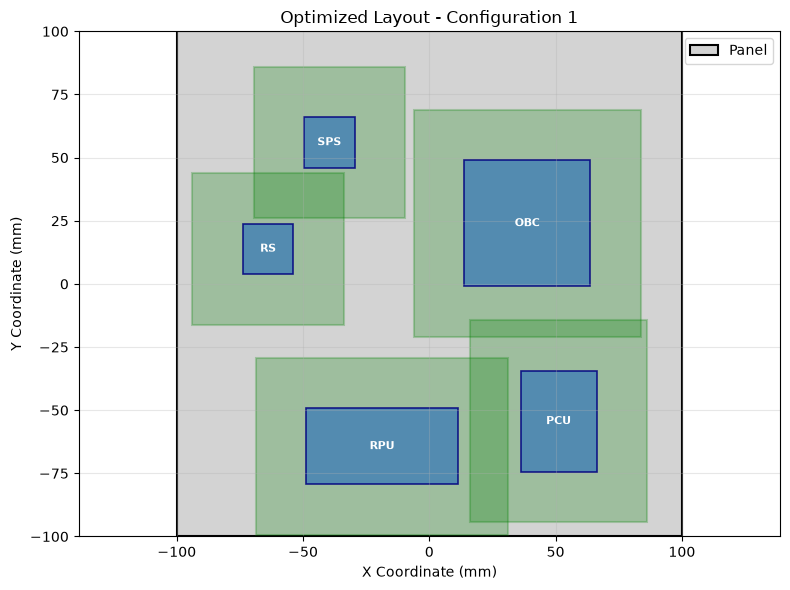

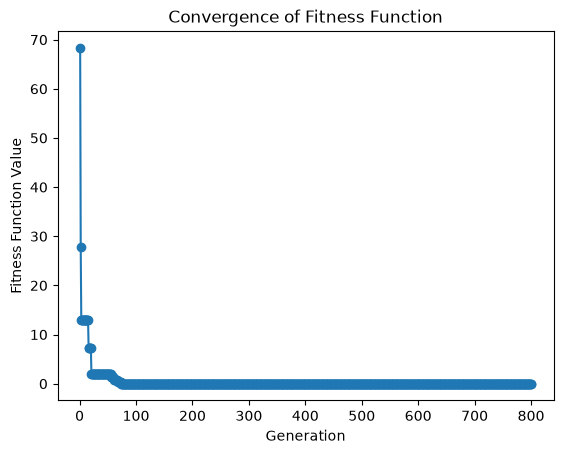

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Configuration 2:
-------------------------------------------------------
CG Offset X: -0.0000 mm | CG Offset Y: 0.0000 mm
Element              Center X        Center Y       
-------------------------------------------------------
PCU                  -44.1447        56.0828        
OBC                  51.6513         37.5660        
SPS                  46.8387         -38.1582       
RPU                  -42.7061        -14.6204       
RS                   -31.6618        -68.2974       


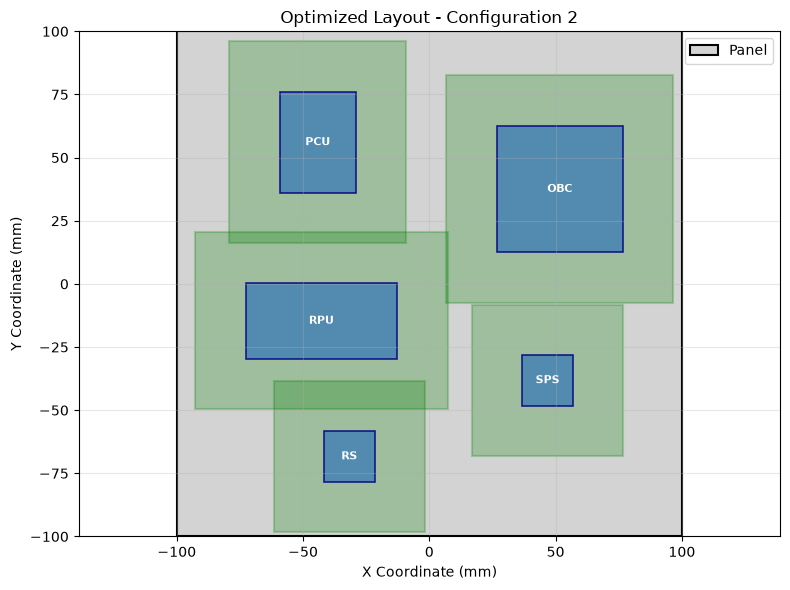

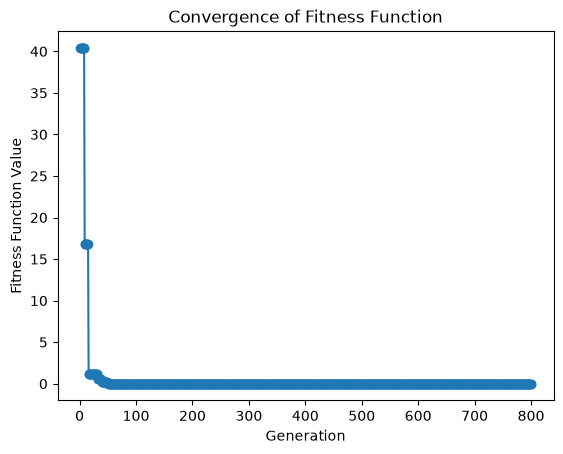

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Configuration 3:
-------------------------------------------------------
CG Offset X: 0.0000 mm | CG Offset Y: 0.0000 mm
Element              Center X        Center Y       
-------------------------------------------------------
PCU                  46.6624         51.7304        
OBC                  -44.0275        -32.0154       
SPS                  68.5042         -5.1205        
RPU                  48.5133         -62.5252       
RS                   -30.2594        23.1073        


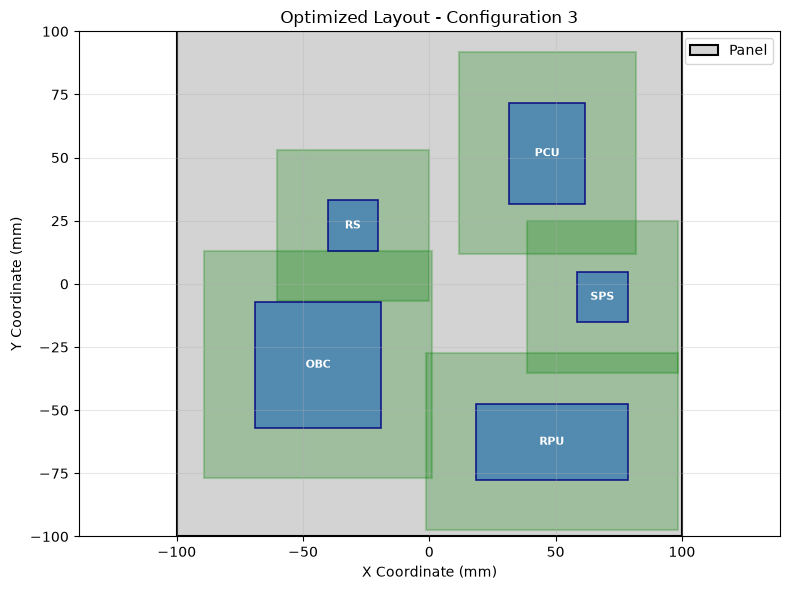

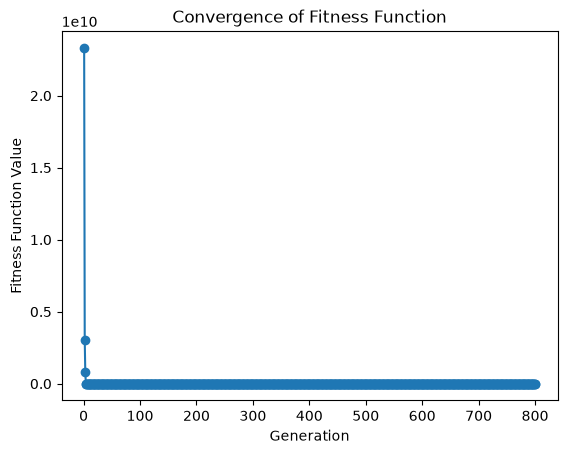

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Configuration 4:
-------------------------------------------------------
CG Offset X: -0.0000 mm | CG Offset Y: 0.0000 mm
Element              Center X        Center Y       
-------------------------------------------------------
PCU                  -19.4509        57.3956        
OBC                  46.7517         29.1335        
SPS                  -22.3161        -0.2682        
RPU                  41.7153         -64.8591       
RS                   -47.2107        -56.5708       


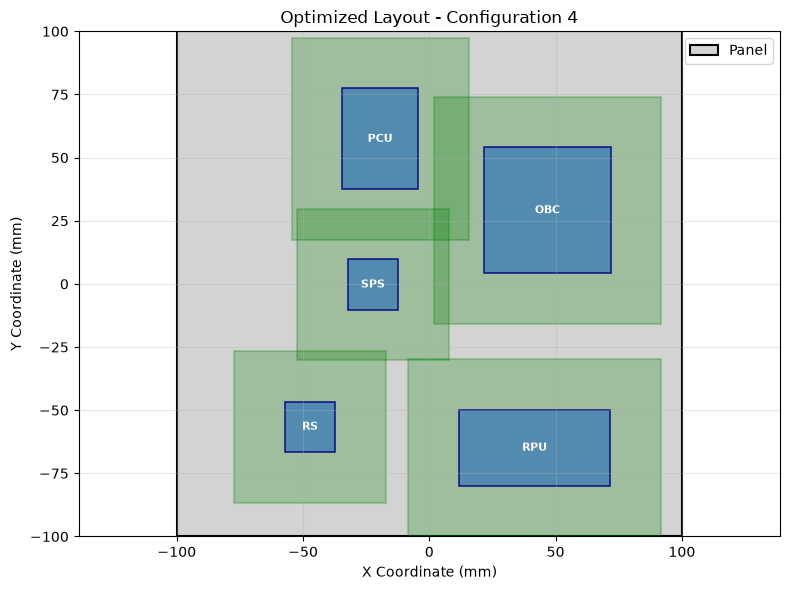

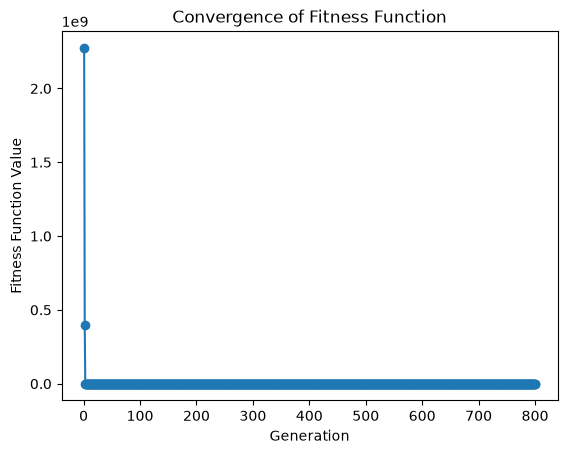

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Configuration 5:
-------------------------------------------------------
CG Offset X: -0.0000 mm | CG Offset Y: 0.0000 mm
Element              Center X        Center Y       
-------------------------------------------------------
PCU                  -55.3419        -0.8432        
OBC                  22.5555         34.5266        
SPS                  -66.6807        58.6202        
RPU                  -41.0758        -62.2847       
RS                   59.5962         -42.8648       


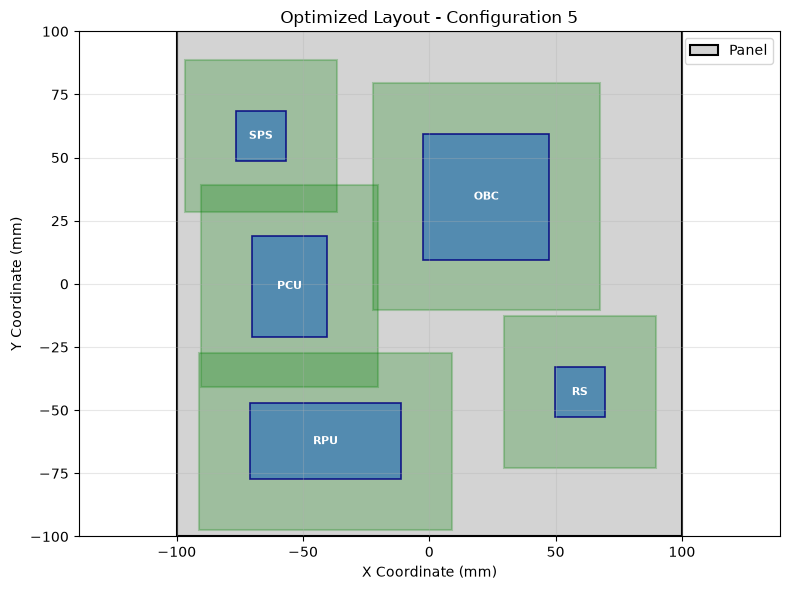

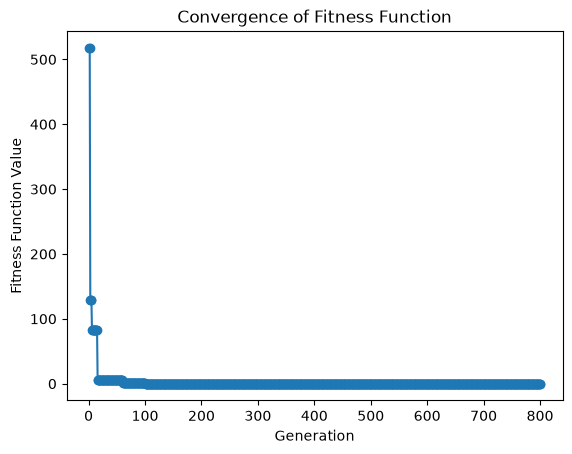

Process complete.


In [6]:
# Constraint 2: Added clearance space
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution

def evaluate(individual, element_data, num_elements, clearance):
    """Computes the squared center-of-gravity offset and applies a continuous
    penalty for any inter-element overlaps or insufficient clearance."""
    masses = element_data[:, 0]
    total_mass = np.sum(masses)
    cg_x = sum(x * m for x, m in zip(individual[::2], masses)) / total_mass
    cg_y = sum(y * m for y, m in zip(individual[1::2], masses)) / total_mass
    base_fitness = cg_x**2 + cg_y**2

    penalty = 0.0
    penalty_scale = 1e8
    for i in range(num_elements):
        xi, yi = individual[2 * i], individual[2 * i + 1]
        li, wi = element_data[i, 1], element_data[i, 2]
        for j in range(i + 1, num_elements):
            xj, yj = individual[2 * j], individual[2 * j + 1]
            lj, wj = element_data[j, 1], element_data[j, 2]
            
            x_penetration = max(0.0, (li + lj) / 2.0 + clearance - abs(xi - xj))
            y_penetration = max(0.0, (wi + wj) / 2.0 + clearance - abs(yi - yj))
            
            if x_penetration > 1e-6 and y_penetration > 1e-6:
                penalty += x_penetration * y_penetration * penalty_scale

    return base_fitness + penalty

def is_feasible(individual, element_data, num_elements, clearance):
    """Strict validation to confirm zero overlap and minimum clearance between all elements."""
    for i in range(num_elements):
        for j in range(i + 1, num_elements):
            xi, yi = individual[2 * i], individual[2 * i + 1]
            xj, yj = individual[2 * j], individual[2 * j + 1]
            li, wi = element_data[i, 1], element_data[i, 2]
            lj, wj = element_data[j, 1], element_data[j, 2]
            
            x_penetration = max(0.0, (li + lj) / 2.0 + clearance - abs(xi - xj))
            y_penetration = max(0.0, (wi + wj) / 2.0 + clearance - abs(yi - yj))
            
            if x_penetration > 1e-4 and y_penetration > 1e-4:
                return False
    return True

def main():
    panel_width = float(input("Enter panel width (in mm): "))
    panel_height = float(input("Enter panel height (in mm): "))
    num_elements = int(input("Enter the number of elements: "))
    border_spacing = float(input("Enter border spacing from all sides (in mm): "))
    clearance = float(input("Enter required clearance between elements (in mm): "))

    element_data = []
    element_names = []
    for i in range(num_elements):
        name = input(f"Enter name of Element {i + 1}: ")
        length = float(input(f"Enter length of Element {i + 1} (in mm): "))
        width = float(input(f"Enter width of Element {i + 1} (in mm): "))
        mass = float(input(f"Enter mass of Element {i + 1} (kg): "))
        element_data.append([mass, length, width])
        element_names.append(name)

    element_data = np.array(element_data, dtype=float)

    working_width = panel_width - 2 * border_spacing
    working_height = panel_height - 2 * border_spacing
    bounds = []
    possible = True

    for i in range(num_elements):
        length = element_data[i, 1]
        width = element_data[i, 2]
        if length > working_width or width > working_height:
            possible = False
            print(f"Design infeasible: Element '{element_names[i]}' ({length}x{width} mm) exceeds the available working area.")
            break
        x_min = -panel_width / 2 + border_spacing + length / 2
        x_max = panel_width / 2 - border_spacing - length / 2
        y_min = -panel_height / 2 + border_spacing + width / 2
        y_max = panel_height / 2 - border_spacing - width / 2
        bounds.append((x_min, x_max))
        bounds.append((y_min, y_max))

    if not possible:
        print("Design infeasible. Please adjust element dimensions, border spacing, or panel size.")
        return

    num_desired = 5
    uniqueness_tolerance = 0.5  # mm
    unique_solutions = []
    solution_convergences = []
    max_attempts = 120

    print(f"Searching for {num_desired} unique non-overlapping configurations (clearance: {clearance} mm)...")

    for attempt in range(1, max_attempts + 1):
        if len(unique_solutions) >= num_desired:
            break
        seed = np.random.randint(0, 1000000)
        conv_data = []

        def track_convergence(x, convergence=None):
            conv_data.append(evaluate(x, element_data, num_elements, clearance))

        result = differential_evolution(
            evaluate, bounds, args=(element_data, num_elements, clearance),
            maxiter=800, popsize=100, tol=1e-6, strategy='best1bin',
            seed=seed, callback=track_convergence
        )
        candidate = result.x

        if not is_feasible(candidate, element_data, num_elements, clearance):
            continue

        is_unique = True
        for existing in unique_solutions:
            if np.max(np.abs(candidate - existing)) < uniqueness_tolerance:
                is_unique = False
                break

        if is_unique:
            unique_solutions.append(candidate)
            solution_convergences.append(list(conv_data))
            print(f"Identified valid unique configuration {len(unique_solutions)}/{num_desired}")

    for idx, sol in enumerate(unique_solutions, 1):
        total_mass = np.sum(element_data[:, 0])
        final_cg_x = sum(x * m for x, m in zip(sol[::2], element_data[:, 0])) / total_mass
        final_cg_y = sum(y * m for y, m in zip(sol[1::2], element_data[:, 0])) / total_mass

        print(f"Configuration {idx}:")
        print("-" * 55)
        print(f"CG Offset X: {final_cg_x:.4f} mm | CG Offset Y: {final_cg_y:.4f} mm")
        print(f"{'Element':<20} {'Center X':<15} {'Center Y':<15}")
        print("-" * 55)
        for i in range(num_elements):
            print(f"{element_names[i]:<20} {sol[2*i]:<15.4f} {sol[2*i+1]:<15.4f}")

        # Plotting Layout
        fig, ax = plt.subplots(figsize=(8, 6))
        ax.set_xlim(-panel_width / 2, panel_width / 2)
        ax.set_ylim(-panel_height / 2, panel_height / 2)
        ax.set_xlabel("X Coordinate (mm)")
        ax.set_ylabel("Y Coordinate (mm)")
        ax.set_title(f"Optimized Layout - Configuration {idx}")
        ax.grid(True, alpha=0.3)
        ax.set_aspect('equal', adjustable='datalim')

        ax.add_patch(plt.Rectangle((-panel_width/2, -panel_height/2), panel_width, panel_height,
                                facecolor='lightgray', edgecolor='black', linewidth=1.5, label="Panel"))

        # Clearance zones (Green)
        for i in range(num_elements):
            cx, cy = sol[2 * i], sol[2 * i + 1]
            lw, wh = element_data[i, 1], element_data[i, 2]
            clearance_rect = plt.Rectangle(
                (cx - lw / 2 - clearance, cy - wh / 2 - clearance),
                lw + 2 * clearance, wh + 2 * clearance,
                facecolor='green', alpha=0.25, edgecolor='green', linewidth=1.5
            )
            ax.add_patch(clearance_rect)

        # Element placements (Blue)
        for i in range(num_elements):
            cx, cy = sol[2 * i], sol[2 * i + 1]
            lw, wh = element_data[i, 1], element_data[i, 2]
            ax.add_patch(plt.Rectangle((cx - lw / 2, cy - wh / 2), lw, wh, facecolor='steelblue', edgecolor='navy', linewidth=1.2, alpha=0.85))
            ax.text(cx, cy, element_names[i], color='white', ha='center', va='center', fontsize=8, fontweight='bold')

        ax.legend(loc='upper right')
        plt.tight_layout()
        plt.show()

        convergence_data = solution_convergences[idx - 1]
        if convergence_data:
            plt.figure()
            plt.plot(range(1, len(convergence_data) + 1), convergence_data, marker='o', linestyle='-')
            plt.xlabel("Generation")
            plt.ylabel("Fitness Function Value")
            plt.title("Convergence of Fitness Function")
            plt.show()

    print("Process complete.")

if __name__ == "__main__":
    main()


Running optimization to generate distinct layouts...
Found layout 1/5.
Found layout 2/5.
Found layout 3/5.
Found layout 4/5.


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Found layout 5/5.

DISPLAYING RESULTS: TABLE ABOVE EACH DIAGRAM

--- Layout 1 ---
Element Name       Center X (mm)   Center Y (mm)   Mass (kg)  Insert Dia (mm)
-------------------------------------------------------------------------
PCU                50.5318         48.1918         1.50       4.0
OBC                30.1013         -28.7256        2.30       6.0
SPS                -36.1246        -53.6548        0.80       4.0
RPU                -27.2227        55.4202         0.70       6.0
RS                 -51.0921        -1.1007         1.90       4.0


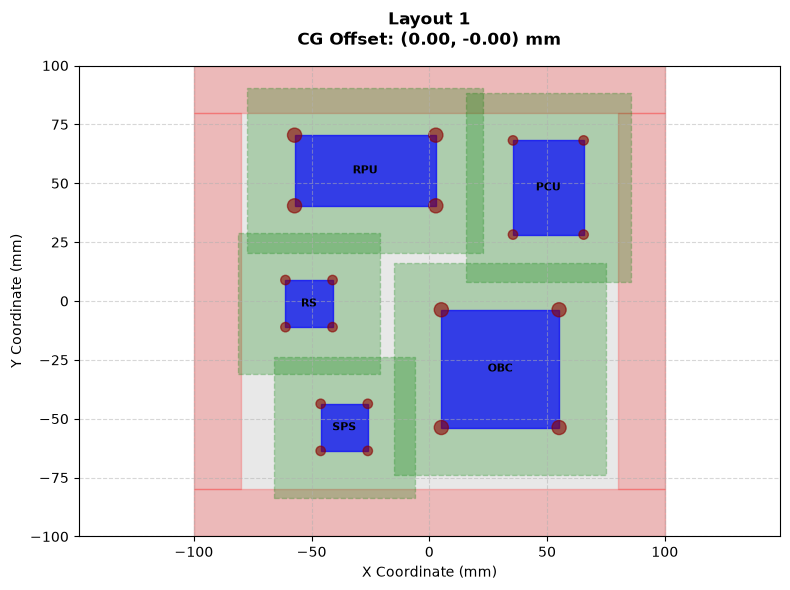

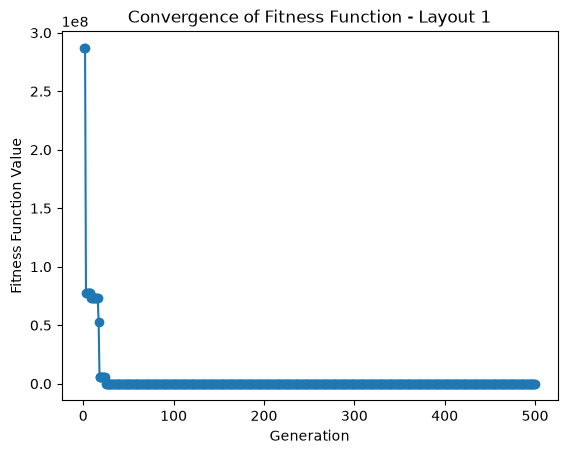

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.



--- Layout 2 ---
Element Name       Center X (mm)   Center Y (mm)   Mass (kg)  Insert Dia (mm)
-------------------------------------------------------------------------
PCU                27.1244         37.6391         1.50       4.0
OBC                -48.8609        49.8258         2.30       6.0
SPS                56.2700         -16.0779        0.80       4.0
RPU                -45.3557        -45.3517        0.70       6.0
RS                 30.7516         -66.5541        1.90       4.0


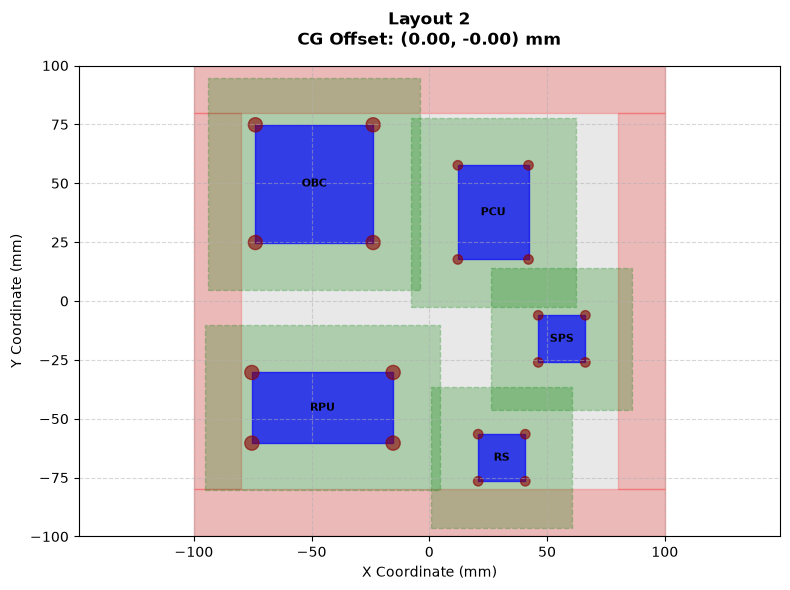

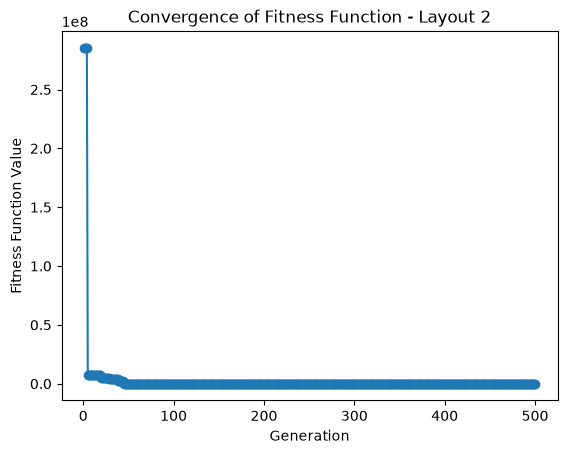

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.



--- Layout 3 ---
Element Name       Center X (mm)   Center Y (mm)   Mass (kg)  Insert Dia (mm)
-------------------------------------------------------------------------
PCU                57.2679         32.4245         1.50       4.0
OBC                -44.1644        -50.2876        2.30       6.0
SPS                -36.6533        16.5597         0.80       4.0
RPU                46.8409         -48.3072        0.70       6.0
RS                 6.4265          46.1010         1.90       4.0


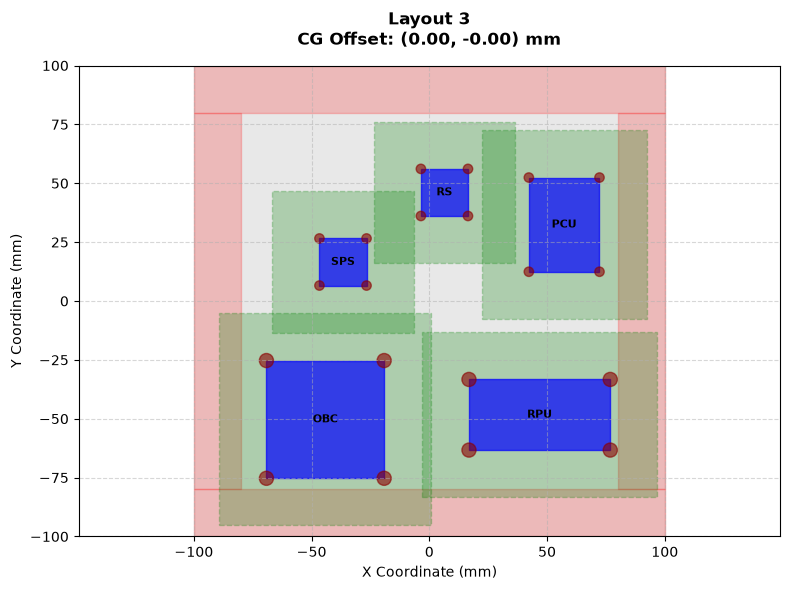

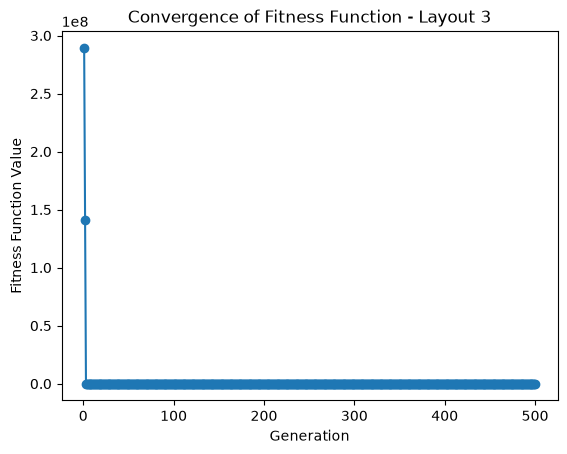

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.



--- Layout 4 ---
Element Name       Center X (mm)   Center Y (mm)   Mass (kg)  Insert Dia (mm)
-------------------------------------------------------------------------
PCU                -38.9083        0.8698          1.50       4.0
OBC                45.6363         -46.0720        2.30       6.0
SPS                -24.4112        -60.4139        0.80       4.0
RPU                40.8779         35.3059         0.70       6.0
RS                 -29.3096        67.5158         1.90       4.0


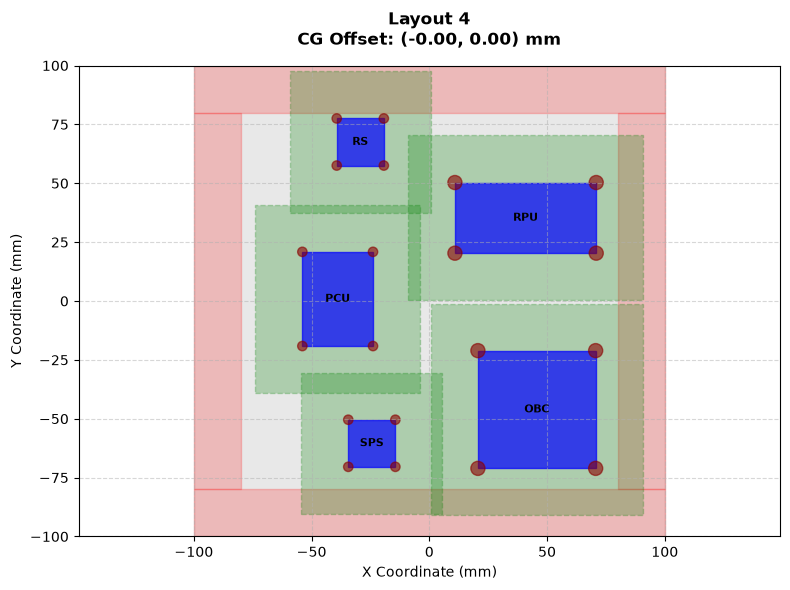

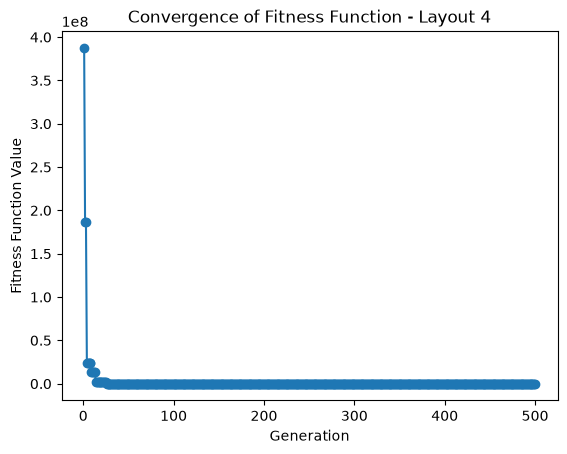

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.



--- Layout 5 ---
Element Name       Center X (mm)   Center Y (mm)   Mass (kg)  Insert Dia (mm)
-------------------------------------------------------------------------
PCU                31.8916         47.2422         1.50       4.0
OBC                50.3029         -40.8367        2.30       6.0
SPS                -16.3964        7.7679          0.80       4.0
RPU                -43.0571        -56.8440        0.70       6.0
RS                 -63.2797        29.8223         1.90       4.0


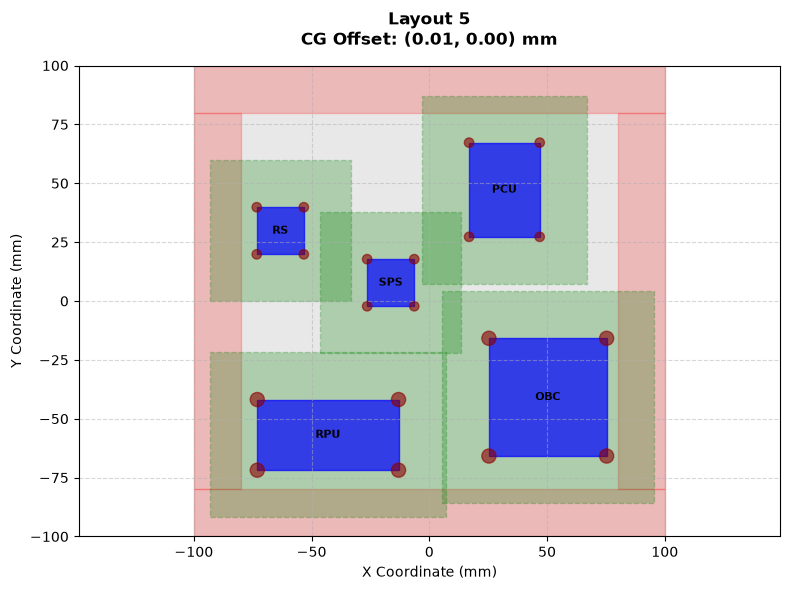

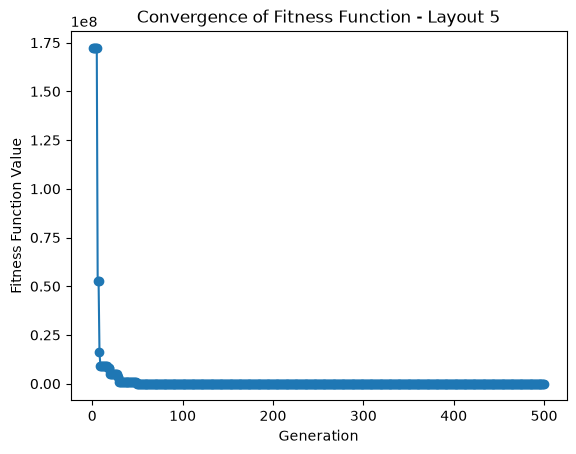

In [8]:
# Constraint 3: Added insert holes
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution
import warnings
warnings.filterwarnings("ignore")

# ================= FAST & ROBUST FITNESS EVALUATION =================
def evaluate(individual, masses, lengths, widths, insert_diams, req_d_matrix, clearance):
    n = len(masses)
    cx = individual[::2]
    cy = individual[1::2]
    hl = lengths / 2.0
    hw = widths / 2.0

    # Center of gravity
    total_mass = np.sum(masses)
    cg_x = np.sum(cx * masses) / total_mass
    cg_y = np.sum(cy * masses) / total_mass
    base_fitness = cg_x**2 + cg_y**2

    penalty = 0.0

    # Vectorized clearance penalty
    diff_x = np.abs(cx[:, None] - cx[None, :])
    diff_y = np.abs(cy[:, None] - cy[None, :])
    req_dx = hl[:, None] + hl[None, :] + clearance
    req_dy = hw[:, None] + hw[None, :] + clearance

    overlap_x = np.maximum(0.0, req_dx - diff_x)
    overlap_y = np.maximum(0.0, req_dy - diff_y)
    mask = np.triu(np.ones((n, n), dtype=bool), k=1)
    penalty += np.sum(overlap_x[mask] * overlap_y[mask]) * 1e6

    # Optimized insert distance penalty (pairwise loop + vectorized 4x4 corners)
    for i in range(n):
        for j in range(i + 1, n):
            xi, yi = cx[i], cy[i]
            xj, yj = cx[j], cy[j]
            li, wi = lengths[i], widths[i]
            lj, wj = lengths[j], widths[j]

            # Corner coordinates
            xi_c = np.array([xi - li/2, xi + li/2, xi - li/2, xi + li/2])
            yi_c = np.array([yi - wi/2, yi - wi/2, yi + wi/2, yi + wi/2])
            xj_c = np.array([xj - lj/2, xj + lj/2, xj - lj/2, xj + lj/2])
            yj_c = np.array([yj - wj/2, yj - wj/2, yj + wj/2, yj + wj/2])

            # 4x4 pairwise distances
            dx = xi_c[:, None] - xj_c[None, :]
            dy = yi_c[:, None] - yj_c[None, :]
            dists = np.sqrt(dx**2 + dy**2)

            req = req_d_matrix[i, j]
            penalty += np.sum(np.maximum(0.0, req - dists)) * 1e6

    return base_fitness + penalty

# ================= USER INPUT PHASE =================
panel_width = float(input("Enter panel width (in mm): "))
panel_height = float(input("Enter panel height (in mm): "))
num_elements = int(input("Enter the number of elements: "))
border_spacing = float(input("Enter border spacing from all sides (in mm): "))
clearance = float(input("Enter required clearance/space between elements (in mm): "))

element_data = []
element_names = []

for i in range(num_elements):
    element_name = input(f"Enter name of Element {i + 1}: ")
    length = float(input(f"Enter length of Element {i + 1} (in mm): "))
    width = float(input(f"Enter width of Element {i + 1} (in mm): "))
    mass = float(input(f"Enter mass of Element {i + 1} (kg): "))
    
    while True:
        insert_diam = float(input(f"Enter insert diameter for {element_name} (4 or 6 mm): "))
        if insert_diam in [4.0, 6.0]:
            break
        print("Invalid diameter. Please enter exactly 4 or 6 mm.")

    element_data.append([mass, length, width, insert_diam])
    element_names.append(element_name)

element_data = np.array(element_data, dtype=float)

# ================= FEASIBILITY & BOUNDS CHECK =================
working_width = panel_width - 2 * border_spacing
working_height = panel_height - 2 * border_spacing
possible = True
bounds = []

for i in range(num_elements):
    length = element_data[i, 1]
    width = element_data[i, 2]
    insert_radius = element_data[i, 3] / 2.0

    if length > working_width or width > working_height:
        possible = False
        print(f"Design impossible: Element '{element_names[i]}' ({length}x{width} mm) exceeds working area.")
        break

    # TIGHTENED BOUNDS: Insert circles cannot cross the red border zone
    x_min = -panel_width / 2 + border_spacing + length / 2 + insert_radius
    x_max = panel_width / 2 - border_spacing - length / 2 - insert_radius
    y_min = -panel_height / 2 + border_spacing + width / 2 + insert_radius
    y_max = panel_height / 2 - border_spacing - width / 2 - insert_radius
    bounds.append((x_min, x_max))
    bounds.append((y_min, y_max))

# ================= MULTI-OUTPUT OPTIMIZATION PHASE =================
if possible:
    masses = element_data[:, 0]
    lengths = element_data[:, 1]
    widths = element_data[:, 2]
    insert_diams = element_data[:, 3]
    n = len(element_data)

    req_d_matrix = np.empty((n, n))
    for i in range(n):
        for j in range(n):
            if insert_diams[i] == 4.0 and insert_diams[j] == 4.0:
                req_d_matrix[i, j] = 24.0
            elif insert_diams[i] == 6.0 and insert_diams[j] == 6.0:
                req_d_matrix[i, j] = 36.0
            else:
                req_d_matrix[i, j] = 30.0

    distinct_layouts = []
    layout_convergences = []
    max_attempts = 300
    attempt = 0

    print("\nRunning optimization to generate distinct layouts...")
    while len(distinct_layouts) < 5 and attempt < max_attempts:
        attempt += 1
        seed = int(np.random.default_rng().integers(0, 2**31 - 1))
        conv_data = []

        def track_convergence(x, convergence=None):
            conv_data.append(evaluate(x, masses, lengths, widths, insert_diams, req_d_matrix, clearance))

        try:
            result = differential_evolution(
                evaluate, bounds,
                args=(masses, lengths, widths, insert_diams, req_d_matrix, clearance),
                maxiter=500, popsize=50, tol=1e-6,
                strategy='best1bin', seed=seed, polish=False,
                updating='deferred', callback=track_convergence
            )
            current_layout = result.x

            if np.any(np.isinf(current_layout)) or np.any(np.isnan(current_layout)):
                continue

            is_distinct = True
            for existing in distinct_layouts:
                if np.max(np.abs(current_layout - existing)) < 1.0:
                    is_distinct = False
                    break

            if is_distinct:
                distinct_layouts.append(current_layout)
                layout_convergences.append(list(conv_data))
                print(f"Found layout {len(distinct_layouts)}/5.")

        except Exception as e:
            print(f"Attempt {attempt} failed: {e}. Continuing...")
            continue

    total_mass = sum(masses)

    # ================= VISUALIZATION & RESULTS PHASE =================
    if len(distinct_layouts) == 0:
        print("\nNo feasible layouts could be generated. Adjust constraints and run again.")
    else:
        print("\n" + "=" * 80)
        print("DISPLAYING RESULTS: TABLE ABOVE EACH DIAGRAM")
        print("=" * 80)

        for idx, layout in enumerate(distinct_layouts):
            layout_idx = idx + 1
            final_cg_x = sum(x * m for x, m in zip(layout[::2], masses)) / total_mass
            final_cg_y = sum(y * m for y, m in zip(layout[1::2], masses)) / total_mass

            # 1. PRINT TABLE ABOVE PLOT
            print(f"\n--- Layout {layout_idx} ---")
            print(f"{'Element Name':<18} {'Center X (mm)':<15} {'Center Y (mm)':<15} {'Mass (kg)':<10} {'Insert Dia (mm)'}")
            print("-" * 73)
            for i in range(num_elements):
                ex = layout[i * 2]
                ey = layout[i * 2 + 1]
                mass = element_data[i, 0]
                diam = element_data[i, 3]
                print(f"{element_names[i]:<18} {ex:<15.4f} {ey:<15.4f} {mass:<10.2f} {diam}")

            # 2. CREATE & DISPLAY RESIZED PLOT
            fig, ax = plt.subplots(figsize=(8, 6))
            ax.set_title(f"Layout {layout_idx}\nCG Offset: ({final_cg_x:.2f}, {final_cg_y:.2f}) mm",
                         fontsize=12, fontweight='bold', pad=15)

            # Panel background
            ax.add_patch(plt.Rectangle((-panel_width/2, -panel_height/2), panel_width, panel_height, color='lightgray', alpha=0.5))

            # Border spacing markers
            border_style = dict(color='red', alpha=0.2)
            ax.add_patch(plt.Rectangle((-panel_width/2, panel_height/2 - border_spacing), panel_width, border_spacing, **border_style))
            ax.add_patch(plt.Rectangle((-panel_width/2, -panel_height/2), panel_width, border_spacing, **border_style))
            ax.add_patch(plt.Rectangle((-panel_width/2, -panel_height/2 + border_spacing), border_spacing, panel_height - 2*border_spacing, **border_style))
            ax.add_patch(plt.Rectangle((panel_width/2 - border_spacing, -panel_height/2 + border_spacing), border_spacing, panel_height - 2*border_spacing, **border_style))

            for i in range(num_elements):
                ex = layout[i * 2]
                ey = layout[i * 2 + 1]
                el_length = lengths[i]
                el_width = widths[i]
                insert_diam = insert_diams[i]
                insert_rad = insert_diam / 2.0

                # Clearance zone
                ax.add_patch(plt.Rectangle((ex - el_length/2 - clearance, ey - el_width/2 - clearance),
                                           el_length + 2*clearance, el_width + 2*clearance,
                                           color='green', alpha=0.25, edgecolor='green', linestyle='--'))

                # Element body
                ax.add_patch(plt.Rectangle((ex - el_length/2, ey - el_width/2), el_length, el_width, color='blue', alpha=0.7))

                # Insert corners
                corners = [
                    (ex - el_length/2, ey - el_width/2),
                    (ex + el_length/2, ey - el_width/2),
                    (ex - el_length/2, ey + el_width/2),
                    (ex + el_length/2, ey + el_width/2)
                ]
                for cx_c, cy_c in corners:
                    ax.add_patch(plt.Circle((cx_c, cy_c), insert_rad, color='darkred', alpha=0.6))

                ax.text(ex, ey, element_names[i], color='black', ha='center', va='center', fontsize=8, fontweight='bold')

            ax.set_xlim(-panel_width/2, panel_width/2)
            ax.set_ylim(-panel_height/2, panel_height/2)
            ax.set_xlabel("X Coordinate (mm)", fontsize=10)
            ax.set_ylabel("Y Coordinate (mm)", fontsize=10)
            ax.set_aspect('equal', adjustable='datalim')
            ax.grid(True, linestyle='--', alpha=0.5)

            plt.tight_layout()
            plt.show()
            plt.close(fig)

            # Plot convergence curve
            convergence_data = layout_convergences[idx]
            if convergence_data:
                plt.figure()
                plt.plot(range(1, len(convergence_data) + 1), convergence_data, marker='o', linestyle='-')
                plt.xlabel("Generation")
                plt.ylabel("Fitness Function Value")
                plt.title(f"Convergence of Fitness Function - Layout {layout_idx}")
                plt.show()

        if len(distinct_layouts) < 5:
            print(f"\nNote: Only {len(distinct_layouts)} distinct layout(s) could be generated within {attempt} attempts.")
            print("The solution space is highly constrained. Adjust parameters to increase diversity.")

else:
    print("Design impossible: The specified constraints cannot be satisfied.")